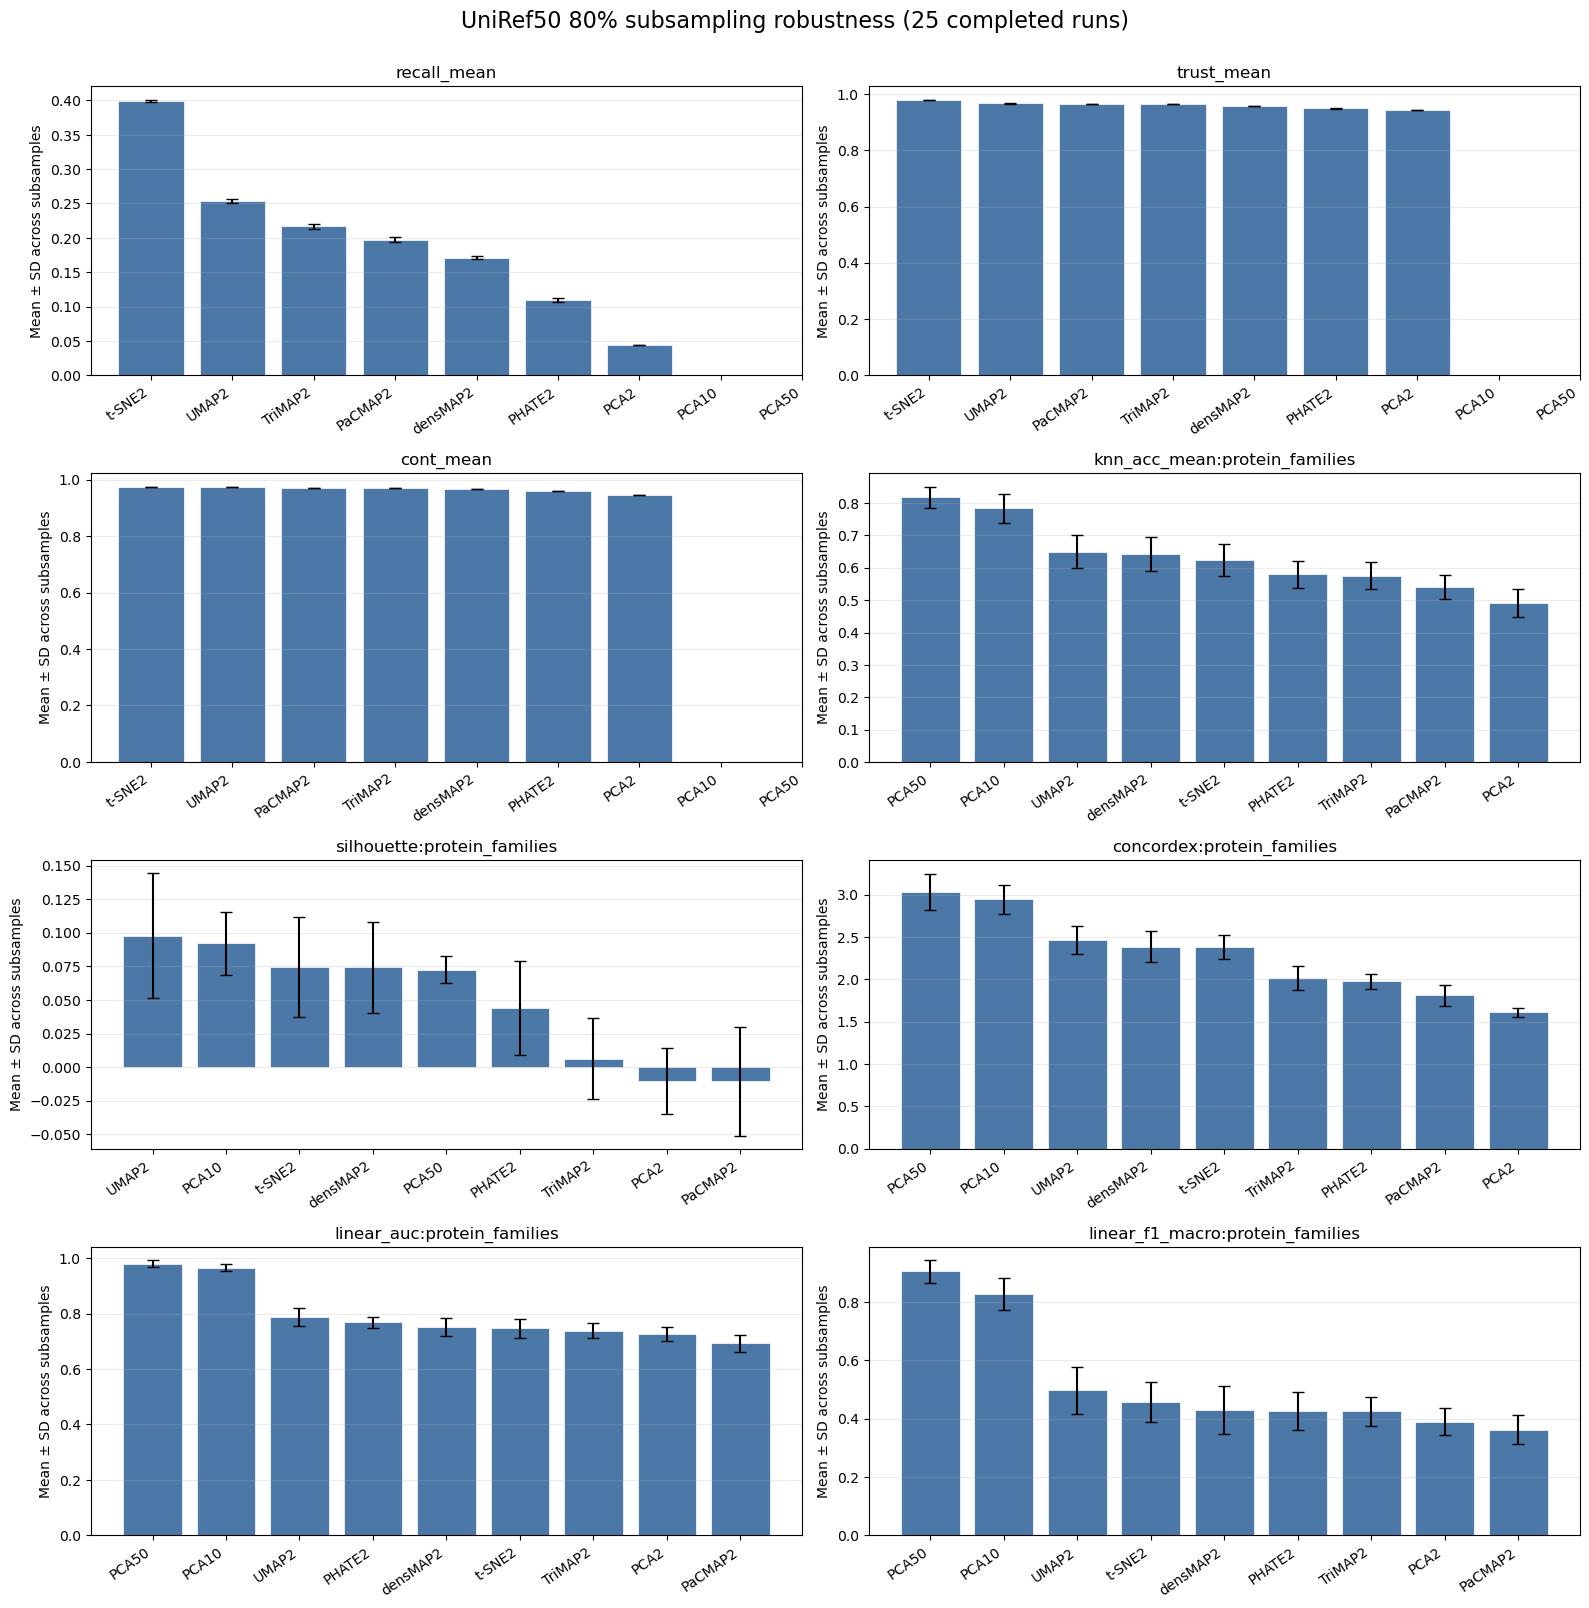

metric,concordex:protein_families,cont_mean,knn_acc_mean:protein_families,linear_auc:protein_families,linear_f1_macro:protein_families,recall_mean,silhouette:protein_families,trust_mean
space,,,,,,,,
PCA10,2.9475,NaN,0.7836,0.9651,0.8262,NaN,0.0922,NaN
PCA2,1.6105,0.9471,0.4900,0.7261,0.3891,0.0438,-0.0102,0.9425
PCA50,3.0335,NaN,0.8177,0.9800,0.9040,NaN,0.0726,NaN
PHATE2,1.9771,0.9591,0.5796,0.7683,0.4266,0.1096,0.0442,0.9492
PaCMAP2,1.8118,0.9717,0.5393,0.6926,0.3623,0.1973,-0.0106,0.9641
TriMAP2,2.0133,0.9705,0.5756,0.7378,0.4250,0.2166,0.0064,0.9639
UMAP2,2.4620,0.9739,0.6503,0.7883,0.4964,0.2537,0.0978,0.9671
densMAP2,2.3848,0.9668,0.6420,0.7531,0.4302,0.1710,0.0742,0.9565
t-SNE2,2.3796,0.9746,0.6245,0.7465,0.4563,0.3989,0.0744,0.9788


,metric,space,mean,std,n
0,recall_mean,PCA10,NaN,NaN,0
1,recall_mean,PCA2,0.043788,0.000406,25
2,recall_mean,PCA50,NaN,NaN,0
3,recall_mean,PHATE2,0.109616,0.003181,25
4,recall_mean,PaCMAP2,0.197256,0.003415,25
5,recall_mean,TriMAP2,0.216628,0.003174,25
6,recall_mean,UMAP2,0.253708,0.002816,25
7,recall_mean,densMAP2,0.171036,0.002140,25
8,recall_mean,t-SNE2,0.398876,0.001670,25
9,trust_mean,PCA10,NaN,NaN,0


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Works whether the notebook is launched from the repository root or PP_project/.
cwd = Path.cwd()
project_dir = cwd if (cwd / "protspace_results").exists() else cwd / "PP_project"
results_dir = project_dir / "protspace_results" / "robustness"
manifest_path = results_dir / "manifest.tsv"

manifest = pd.read_csv(manifest_path, sep="\t")
completed = manifest[manifest["summary_path"].fillna("").ne("")].copy()

summary_frames = []
for row in completed.itertuples(index=False):
    summary_path = Path(row.summary_path)
    if not summary_path.is_absolute():
        summary_path = project_dir.parent / summary_path
    if not summary_path.exists():
        print(f"Skipping missing summary: {summary_path}")
        continue

    summary = pd.read_csv(summary_path, sep="\t", comment="#")
    summary["run_id"] = row.run_id
    summary["subset_seed"] = row.subset_seed
    summary["run_seed"] = row.run_seed
    summary_frames.append(summary)

if not summary_frames:
    raise FileNotFoundError(f"No readable summary.tsv files found via {manifest_path}")

all_summaries = pd.concat(summary_frames, ignore_index=True)

# Keep actual requested projections; drop evaluation baselines such as Original/PCA(50).
space = all_summaries["space"].astype(str)
is_baseline = space.str.startswith("Original") | space.str.match(r"^PCA\s*\(") | space.str.match(r"^PCA10\s*\(")
plot_data = all_summaries.loc[~is_baseline].copy()

# Primary metrics only: plot metric values across the 50 subsamples, not per-run std columns.
id_columns = {"space", "type", "run_id", "subset_seed", "run_seed"}
metric_columns = []
for column in plot_data.columns:
    if column in id_columns:
        continue
    if column.endswith("_std") or "_mean_std" in column:
        continue
    values = pd.to_numeric(plot_data[column], errors="coerce")
    if values.notna().any():
        plot_data[column] = values
        metric_columns.append(column)

preferred_order = [
    "recall_mean",
    "trust_mean",
    "cont_mean",
]
supervised_order = [
    column
    for prefix in [
        "knn_acc_mean:",
        "silhouette:",
        "concordex:",
        "linear_auc:",
        "linear_f1_macro:",
        "linear_r2:",
        "knn_r2:",
        "distance_correlation:",
        "spearman_dcorr:",
    ]
    for column in metric_columns
    if column.startswith(prefix)
]
ordered_metrics = [m for m in preferred_order if m in metric_columns] + [
    m for m in supervised_order if m not in preferred_order
]
ordered_metrics += [m for m in metric_columns if m not in ordered_metrics]

aggregate_parts = []
for metric in ordered_metrics:
    part = (
        plot_data.groupby("space", observed=True)[metric]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
    )
    part.insert(0, "metric", metric)
    aggregate_parts.append(part)
aggregate = pd.concat(aggregate_parts, ignore_index=True)
aggregate.to_csv(results_dir / "robustness_summary_aggregate.tsv", sep="\t", index=False)

n_metrics = len(ordered_metrics)
n_cols = 2
n_rows = int(np.ceil(n_metrics / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, max(4, 4 * n_rows)), squeeze=False)
axes = axes.ravel()

for ax, metric in zip(axes, ordered_metrics, strict=False):
    metric_df = aggregate[aggregate["metric"] == metric].copy()
    metric_df = metric_df.sort_values("mean", ascending=False)
    x = np.arange(len(metric_df))
    ax.bar(
        x,
        metric_df["mean"],
        yerr=metric_df["std"].fillna(0),
        capsize=4,
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_df["space"], rotation=35, ha="right")
    ax.set_ylabel("Mean ± SD across subsamples")
    ax.grid(axis="y", alpha=0.25)

for ax in axes[n_metrics:]:
    ax.axis("off")

fig.suptitle(
    f"UniRef50 80% subsampling robustness ({plot_data['run_id'].nunique()} completed runs)",
    y=1.002,
    fontsize=16,
)
fig.tight_layout()
fig.savefig(results_dir / "robustness_metric_errorbars.png", dpi=180, bbox_inches="tight")
plt.show()

display(aggregate.pivot(index="space", columns="metric", values="mean").round(4))
display(aggregate.head(20))
